In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

In [2]:
# Setting random seeds for reproducibility
import tensorflow as tf
np.random.seed(42)
tf.random.set_seed(42)

In [3]:
train_df = pd.read_csv('data/train_processed.csv')
feature_cols = joblib.load('data/feature_columns.pkl')

In [4]:
def create_sequences(df, sequence_length=50):
    """
    Convert tabular data into sequences for CNN.
    Same as LSTM - CNN also works on sequences!
    """
    sequences = []
    targets = []

    # Group by engine
    for engine_id in df['unit_id'].unique():
        engine_data = df[df['unit_id'] == engine_id].sort_values('time_cycles')

        # Extract features and RUL
        features = engine_data[feature_cols].values
        rul = engine_data['RUL'].values

        # Create sequences
        for i in range(sequence_length, len(features)):
            # Take last 'sequence_length' timesteps
            seq = features[i-sequence_length:i]
            target = rul[i]

            sequences.append(seq)
            targets.append(target)

    return np.array(sequences), np.array(targets)

In [5]:
# Create sequences
sequence_length = 50
print(f"\nCreating sequences with window size: {sequence_length} cycles")


Creating sequences with window size: 50 cycles


In [6]:
X, y = create_sequences(train_df, sequence_length)

In [7]:
print("\nSequence preparation completed!")

print(f"X shape : {X.shape}")   # (samples, timesteps, features)
print(f"y shape : {y.shape}")

print("\nDataset Breakdown:")
print(f"  • Total sequences        : {X.shape[0]:,}")
print(f"  • Timesteps in sequence  : {X.shape[1]}")
print(f"  • Features per timestep  : {X.shape[2]}")


Sequence preparation completed!
X shape : (15631, 50, 17)
y shape : (15631,)

Dataset Breakdown:
  • Total sequences        : 15,631
  • Timesteps in sequence  : 50
  • Features per timestep  : 17


In [8]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# **CNN**

In [9]:
class CNNModel(nn.Module):
    def __init__(self, input_size):
        super(CNNModel, self).__init__()

        # First Convolutional Block
        self.block1 = nn.Sequential(
            nn.Conv1d(in_channels=input_size, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.MaxPool1d(kernel_size=2),
            nn.Dropout(0.2)
        )

        # Second Convolutional Block
        self.block2 = nn.Sequential(
            nn.Conv1d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.MaxPool1d(kernel_size=2),
            nn.Dropout(0.2)
        )

        # Third Convolutional Block (GlobalMaxPool → AdaptiveMaxPool1d(1))
        self.block3 = nn.Sequential(
            nn.Conv1d(in_channels=128, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.AdaptiveMaxPool1d(1),   # equivalent to GlobalMaxPooling1D
            nn.Dropout(0.3)
        )

        # Dense layers
        self.fc = nn.Sequential(
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        # Keras Conv1D expects (batch, steps, features)
        # PyTorch Conv1d expects (batch, features, steps) → permute
        x = x.permute(0, 2, 1)   # (batch, input_size, seq_len)

        x = self.block1(x)        # (batch, 64,  seq_len/2)
        x = self.block2(x)        # (batch, 128, seq_len/4)
        x = self.block3(x)        # (batch, 64,  1)
        x = x.squeeze(-1)         # (batch, 64)

        x = self.fc(x)            # (batch, 1)
        return x


In [10]:
input_size = X.shape[2]
model = CNNModel(input_size=input_size)

print("\n Model Architecture:")
print(model)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal params:     {total_params:,}")
print(f"Trainable params: {trainable_params:,}")


 Model Architecture:
CNNModel(
  (block1): Sequential(
    (0): Conv1d(17, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): ReLU()
    (2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout(p=0.2, inplace=False)
  )
  (block2): Sequential(
    (0): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): ReLU()
    (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout(p=0.2, inplace=False)
  )
  (block3): Sequential(
    (0): Conv1d(128, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): ReLU()
    (2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): AdaptiveMaxPool1d(output_size=1)
    (4): Dropout(p=0.3, inplace=False)
  )
  (fc): Sequential(
    (0): Lin

In [11]:
try:
    import torchinfo
except ImportError:
    !pip install -qq torchinfo
    import torchinfo

torchinfo.summary(model, input_size=(1, sequence_length, X.shape[2]))

Layer (type:depth-idx)                   Output Shape              Param #
CNNModel                                 [1, 1]                    --
├─Sequential: 1-1                        [1, 64, 25]               --
│    └─Conv1d: 2-1                       [1, 64, 50]               3,328
│    └─ReLU: 2-2                         [1, 64, 50]               --
│    └─BatchNorm1d: 2-3                  [1, 64, 50]               128
│    └─MaxPool1d: 2-4                    [1, 64, 25]               --
│    └─Dropout: 2-5                      [1, 64, 25]               --
├─Sequential: 1-2                        [1, 128, 12]              --
│    └─Conv1d: 2-6                       [1, 128, 25]              24,704
│    └─ReLU: 2-7                         [1, 128, 25]              --
│    └─BatchNorm1d: 2-8                  [1, 128, 25]              256
│    └─MaxPool1d: 2-9                    [1, 128, 12]              --
│    └─Dropout: 2-10                     [1, 128, 12]              --
├─Sequ

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_val_t   = torch.tensor(X_val,   dtype=torch.float32)
y_val_t   = torch.tensor(y_val,   dtype=torch.float32).unsqueeze(1)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=64, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val_t,   y_val_t),   batch_size=64, shuffle=False)

model = model.to(device)

Using device: cuda


In [13]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5,
    min_lr=1e-7
)

print("Optimizer, loss, and scheduler ready.")

Optimizer, loss, and scheduler ready.


In [14]:
epochs           = 100
patience         = 15
best_val_loss    = float('inf')
best_weights     = None
patience_counter = 0
history          = {'train_loss': [], 'val_loss': [], 'train_mae': [], 'val_mae': []}

for epoch in range(1, epochs + 1):

    # ── Train ──
    model.train()
    train_loss, train_mae = 0.0, 0.0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        preds = model(X_batch)
        loss  = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * X_batch.size(0)
        train_mae  += torch.mean(torch.abs(preds - y_batch)).item() * X_batch.size(0)

    train_loss /= len(train_loader.dataset)
    train_mae  /= len(train_loader.dataset)

    # ── Validate ──
    model.eval()
    val_loss, val_mae = 0.0, 0.0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            preds    = model(X_batch)
            loss     = criterion(preds, y_batch)
            val_loss += loss.item() * X_batch.size(0)
            val_mae  += torch.mean(torch.abs(preds - y_batch)).item() * X_batch.size(0)

    val_loss /= len(val_loader.dataset)
    val_mae  /= len(val_loader.dataset)

    # ── Log ──
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_mae'].append(train_mae)
    history['val_mae'].append(val_mae)

    print(f"Epoch {epoch:3d}/{epochs} — "
          f"loss: {train_loss:.4f}  mae: {train_mae:.4f}  "
          f"val_loss: {val_loss:.4f}  val_mae: {val_mae:.4f}")

    # ── ReduceLROnPlateau ──
    scheduler.step(val_loss)

    # ── EarlyStopping ──
    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        best_weights     = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\nEarly stopping at epoch {epoch}.")
            print(f"Restoring best weights (val_loss: {best_val_loss:.4f})")
            break

model.load_state_dict(best_weights)

Epoch   1/100 — loss: 2989.5205  mae: 38.0412  val_loss: 1036.5434  val_mae: 22.3419
Epoch   2/100 — loss: 1145.8802  mae: 24.3453  val_loss: 689.8022  val_mae: 18.9908
Epoch   3/100 — loss: 931.4743  mae: 21.9987  val_loss: 414.8058  val_mae: 15.0397
Epoch   4/100 — loss: 820.6653  mae: 20.7714  val_loss: 402.2594  val_mae: 15.0028
Epoch   5/100 — loss: 738.7227  mae: 19.6642  val_loss: 285.4882  val_mae: 12.9078
Epoch   6/100 — loss: 683.8080  mae: 18.9520  val_loss: 391.8639  val_mae: 13.6877
Epoch   7/100 — loss: 610.6777  mae: 18.1055  val_loss: 374.3353  val_mae: 14.9163
Epoch   8/100 — loss: 598.8183  mae: 17.8878  val_loss: 207.3714  val_mae: 10.7064
Epoch   9/100 — loss: 605.3848  mae: 17.9695  val_loss: 177.5058  val_mae: 9.9090
Epoch  10/100 — loss: 557.6105  mae: 17.2940  val_loss: 214.3487  val_mae: 10.9186
Epoch  11/100 — loss: 522.2652  mae: 16.7445  val_loss: 335.2103  val_mae: 13.4702
Epoch  12/100 — loss: 508.6912  mae: 16.5407  val_loss: 138.2411  val_mae: 8.9201
Epo

<All keys matched successfully>

In [15]:
def predict(model, X_numpy, device, batch_size=64):
    """Run inference on a numpy array, return numpy predictions."""
    model.eval()
    X_tensor = torch.tensor(X_numpy, dtype=torch.float32)
    loader   = DataLoader(TensorDataset(X_tensor), batch_size=batch_size, shuffle=False)
    preds    = []

    with torch.no_grad():
        for (X_batch,) in loader:
            X_batch = X_batch.to(device)
            preds.append(model(X_batch).cpu().numpy())

    return np.concatenate(preds).flatten()

In [16]:
# ── Predictions ───────────────────────────────────────────────────
y_train_pred = predict(model, X_train, device)
y_val_pred   = predict(model, X_val,   device)

# ── Metrics ───────────────────────────────────────────────────────
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_mae  = mean_absolute_error(y_train, y_train_pred)
train_r2   = r2_score(y_train, y_train_pred)

val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
val_mae  = mean_absolute_error(y_val, y_val_pred)
val_r2   = r2_score(y_val, y_val_pred)

print(f"\n CNN Results:")
print(f"\nTraining Set:")
print(f"  RMSE: {train_rmse:.2f} cycles")
print(f"  MAE:  {train_mae:.2f} cycles")
print(f"  R²:   {train_r2:.4f}")
print(f"\nValidation Set:")
print(f"  RMSE: {val_rmse:.2f} cycles")
print(f"  MAE:  {val_mae:.2f} cycles")
print(f"  R²:   {val_r2:.4f}")


 CNN Results:

Training Set:
  RMSE: 7.46 cycles
  MAE:  5.69 cycles
  R²:   0.9829

Validation Set:
  RMSE: 8.49 cycles
  MAE:  6.34 cycles
  R²:   0.9780


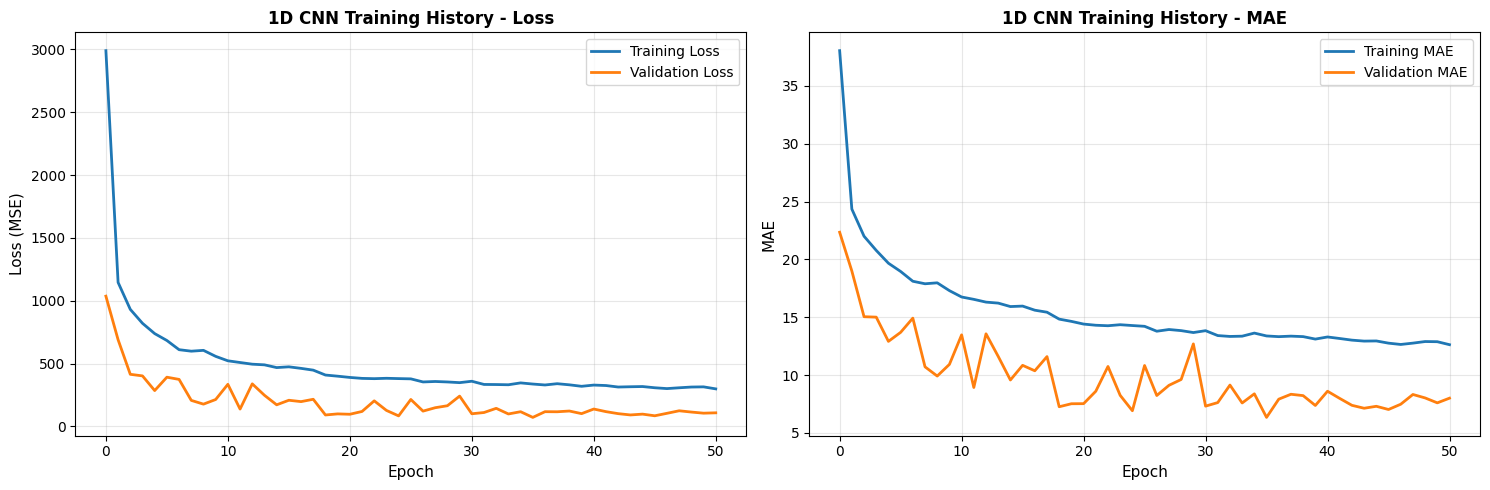

In [17]:
# Training History
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss
axes[0].plot(history['train_loss'], label='Training Loss', linewidth=2)
axes[0].plot(history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=11)
axes[0].set_ylabel('Loss (MSE)', fontsize=11)
axes[0].set_title('1D CNN Training History - Loss', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# MAE
axes[1].plot(history['train_mae'], label='Training MAE', linewidth=2)
axes[1].plot(history['val_mae'], label='Validation MAE', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=11)
axes[1].set_ylabel('MAE', fontsize=11)
axes[1].set_title('1D CNN Training History - MAE', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

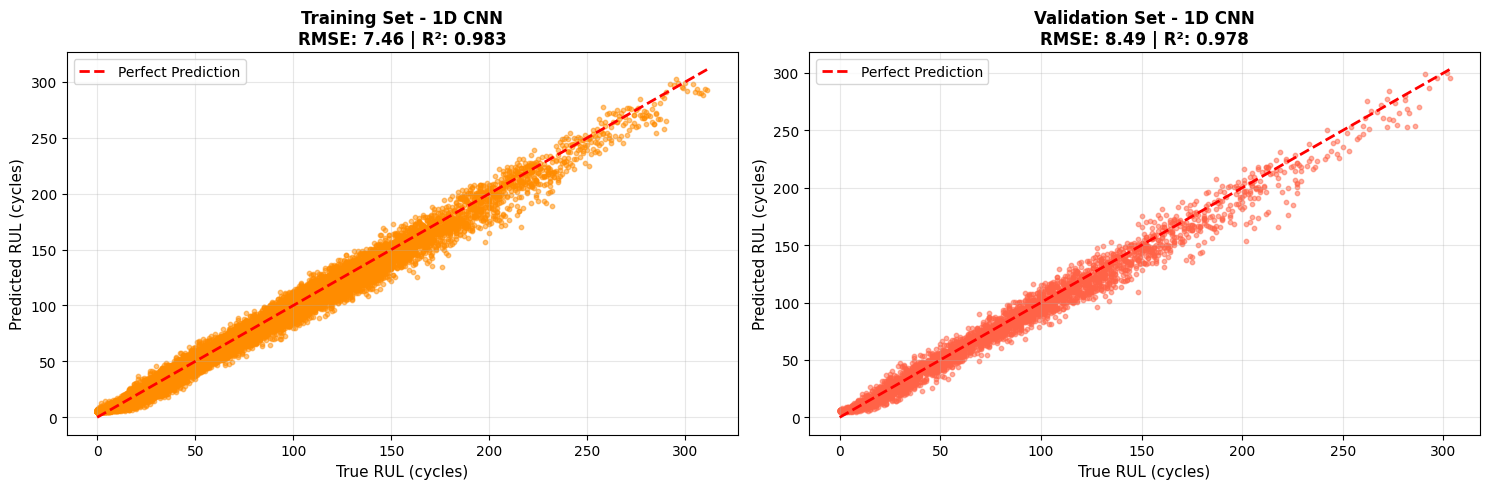

In [18]:
# Predictions vs Actual
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Training
axes[0].scatter(y_train, y_train_pred, alpha=0.5, s=10, color='darkorange')
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()],
             'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('True RUL (cycles)', fontsize=11)
axes[0].set_ylabel('Predicted RUL (cycles)', fontsize=11)
axes[0].set_title(f'Training Set - 1D CNN\nRMSE: {train_rmse:.2f} | R²: {train_r2:.3f}',
                  fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Validation
axes[1].scatter(y_val, y_val_pred, alpha=0.5, s=10, color='tomato')
axes[1].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()],
             'r--', lw=2, label='Perfect Prediction')
axes[1].set_xlabel('True RUL (cycles)', fontsize=11)
axes[1].set_ylabel('Predicted RUL (cycles)', fontsize=11)
axes[1].set_title(f'Validation Set - 1D CNN\nRMSE: {val_rmse:.2f} | R²: {val_r2:.3f}',
                  fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()